# Einstichproben-t-Test – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/einfacher-t-test)

Der **Einstichproben-t-Test** (auch: einfacher t-Test) prüft, ob der Mittelwert
einer Stichprobe signifikant von einem **bekannten Referenzwert** abweicht.

**Wann verwenden?**
> Ich habe **eine Stichprobe** und möchte wissen, ob ihr Mittelwert sich von
> einem festgelegten Wert (Norm, Standard, Sollwert) unterscheidet.

**Formel:**
$$t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}}, \quad df = n - 1$$

| Symbol | Bedeutung |
|---|---|
| $\bar{x}$ | Stichproben-Mittelwert |
| $\mu_0$ | Bekannter Referenz- / Testwert (H₀) |
| $s$ | Stichproben-Standardabweichung |
| $n$ | Stichprobengröße |
| $df$ | Freiheitsgrade = $n - 1$ |

**Voraussetzungen:**
- Eine Stichprobe + ein bekannter Vergleichswert
- Metrisches Skalenniveau
- Normalverteilung (ab n > 30 robust)
- Zufallsstichprobe

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import t as t_dist, norm as norm_dist

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Anwendungsbeispiele (numiqo)

| Bereich | Fragestellung | Referenzwert μ₀ |
|---|---|---|
| **Sozialwiss.** | Unterscheidet sich das Gesundheitsempfinden von Managerinnen von der Gesamtbevölkerung? | Populationsmittelwert |
| **Technik** | Wiegen die hergestellten Schrauben wirklich 10 g? | 10 g (Sollgewicht) |
| **Medizin** | Senkt das Medikament den Blutdruck um 10 mmHg? | 10 mmHg (Versprechen) |
| **Bildung** | Hat das neue Online-Tutorium die Prüfungspunkte beeinflusst? | 28 Punkte (langjähriger Durchschnitt) |

**Alle Beispiele haben dasselbe Prinzip:**
Eine Stichprobe wird mit einem **festgelegten Wert** verglichen –
nicht mit einer anderen Stichprobe.

## 2. Hypothesen formulieren

### Zweiseitig (ungerichtet) – Standard
$$H_0: \mu = \mu_0 \qquad H_1: \mu \neq \mu_0$$
> „Gibt es irgendeinen Unterschied?" – Richtung egal

### Einseitig rechts (gerichtet)
$$H_0: \mu \leq \mu_0 \qquad H_1: \mu > \mu_0$$
> „Ist der Mittelwert **größer** als der Referenzwert?"

### Einseitig links (gerichtet)
$$H_0: \mu \geq \mu_0 \qquad H_1: \mu < \mu_0$$
> „Ist der Mittelwert **kleiner** als der Referenzwert?"

**numiqo-Beispiel (Online-Tutorium):**
- H₀: Die Punktezahl unterscheidet sich **nicht** von 28 (μ = 28)
- H₁: Die Punktezahl unterscheidet sich von 28 (μ ≠ 28)  ← zweiseitig

## 3. Das numiqo-Beispiel: Online-Statistik-Tutorium

**Situation:** An einer Uni liegt der langjährige Durchschnitt bei **28 Punkten**.
Dieses Semester wurde ein neues Online-Tutorium eingeführt.
Wirkt es sich auf die Prüfungsergebnisse aus?

**Datensatz (n = 12):**

| Studierende | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| Punktezahl | 28 | 29 | 35 | 37 | 32 | 26 | 37 | 39 | 22 | 29 | 36 | 38 |

**Erwartete Ergebnisse (numiqo):**

| Kennzahl | Wert |
|---|---|
| n | 12 |
| Mittelwert | 32,33 |
| Standardabweichung | 5,47 |
| Standardfehler | 1,58 |
| t-Wert | 2,75 |
| df | 11 |
| p-Wert (zweiseitig) | 0,02 |
| 95%-KI Differenz | [0,86; 7,81] |

In [9]:
# numiqo-Hauptbeispiel: Online-Statistik-Tutorium
punkte = pd.Series([28, 29, 35, 37, 32, 26, 37, 39, 22, 29, 36, 38])
mu_null = 28.0  # Referenzwert: langjähriger Durchschnitt

n   = len(punkte)
mw  = punkte.mean()
s   = punkte.std(ddof=1)
se  = s / np.sqrt(n)
df  = n - 1

# t-Wert manuell
t_manuell = (mw - mu_null) / se
p_zwei    = 2 * t_dist.sf(abs(t_manuell), df=df)
ki_diff   = t_dist.interval(0.95, df=df, loc=mw-mu_null, scale=se)

print("Einstichproben-t-Test: Online-Tutorium (numiqo)")
print(f"H0: mu = {mu_null}  |  H1: mu != {mu_null}  (zweiseitig)")
print()
print("Statistiken")
print(f"n:                {n}")
print(f"Mittelwert (x):   {mw:.2f}     (numiqo: 32,33)")
print(f"Standardabw. (s): {s:.2f}     (numiqo:  5,47)")
print(f"Standardfehler:   {se:.4f}   (numiqo:  1,58)")
print()
print("Einstichproben-t-Test (Testwert = 28)")
print(f"t-Wert:           {t_manuell:.4f}   (numiqo:  2,75)")
print(f"df:               {df}         (numiqo: 11)")
print(f"p-Wert (2-seit.): {p_zwei:.4f}   (numiqo:  0,02)")
print()
print("95%-Konfidenzintervall der Differenz")
print(f"Mittelwertdiff.:  {mw-mu_null:.2f}")
print(f"Untere Grenze:    {ki_diff[0]:.2f}     (numiqo:  0,86)")
print(f"Obere Grenze:     {ki_diff[1]:.2f}     (numiqo:  7,81)")
print()

# Verifikation mit scipy
t_scipy, p_scipy = stats.ttest_1samp(punkte, popmean=mu_null)
print(f"Kontrolle scipy: t={t_scipy:.4f}, p={p_scipy:.4f}")
print()

alpha = 0.05
if p_zwei < alpha:
    print(f"Entscheidung: p={p_zwei:.4f} < alpha={alpha} -> H0 ABGELEHNT")
    print("Das Online-Tutorium hat die Prüfungsergebnisse signifikant verändert!")
else:
    print(f"Entscheidung: p={p_zwei:.4f} >= alpha={alpha} -> H0 nicht abgelehnt")

# KI: enthält 0?
ki_enthaelt_null = ki_diff[0] <= 0 <= ki_diff[1]
print(f"KI [{ki_diff[0]:.2f}, {ki_diff[1]:.2f}] enthält 0: {ki_enthaelt_null}"
      + " -> nicht signifikant" if ki_enthaelt_null else " -> signifikant")

Einstichproben-t-Test: Online-Tutorium (numiqo)
H0: mu = 28.0  |  H1: mu != 28.0  (zweiseitig)

Statistiken
n:                12
Mittelwert (x):   32.33     (numiqo: 32,33)
Standardabw. (s): 5.47     (numiqo:  5,47)
Standardfehler:   1.5779   (numiqo:  1,58)

Einstichproben-t-Test (Testwert = 28)
t-Wert:           2.7462   (numiqo:  2,75)
df:               11         (numiqo: 11)
p-Wert (2-seit.): 0.0190   (numiqo:  0,02)

95%-Konfidenzintervall der Differenz
Mittelwertdiff.:  4.33
Untere Grenze:    0.86     (numiqo:  0,86)
Obere Grenze:     7.81     (numiqo:  7,81)

Kontrolle scipy: t=2.7462, p=0.0190

Entscheidung: p=0.0190 < alpha=0.05 -> H0 ABGELEHNT
Das Online-Tutorium hat die Prüfungsergebnisse signifikant verändert!
 -> signifikant


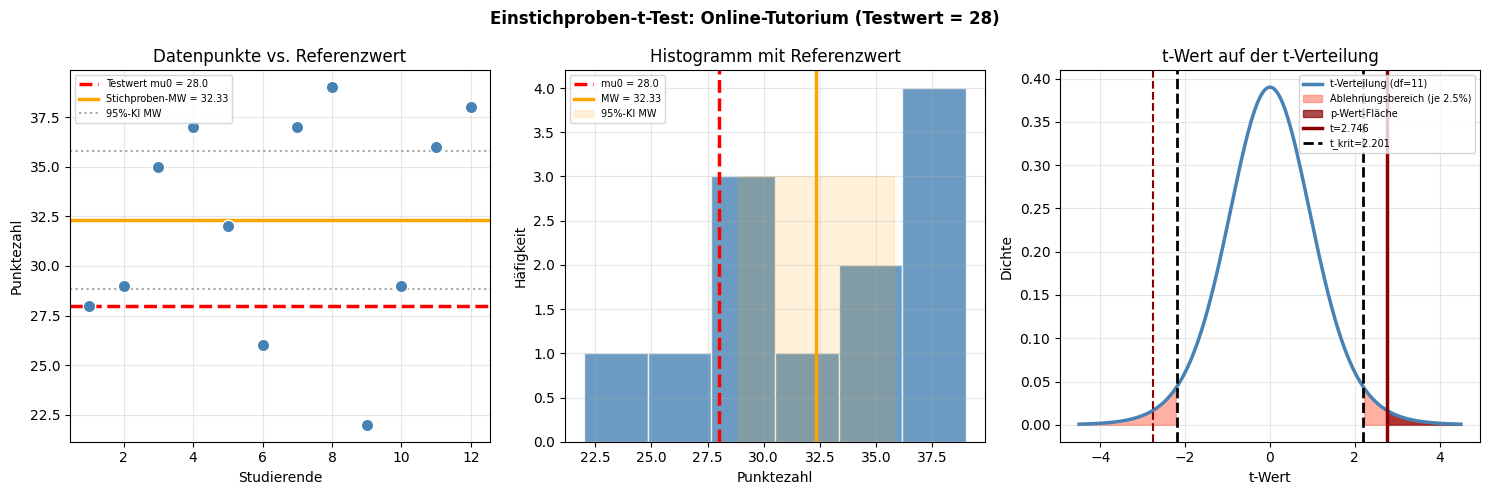

In [10]:
# Vollständige Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Einstichproben-t-Test: Online-Tutorium (Testwert = 28)",
             fontsize=12, fontweight="bold")

# 1. Datenpunkte + Referenz
axes[0].scatter(range(1, n+1), punkte, color="steelblue",
                s=80, edgecolors="white", zorder=3)
axes[0].axhline(mu_null, color="red",    linestyle="--", linewidth=2.5,
                label="Testwert mu0 = " + str(mu_null))
axes[0].axhline(mw,     color="orange", linestyle="-",  linewidth=2.5,
                label="Stichproben-MW = " + str(round(mw, 2)))
axes[0].axhline(ki_diff[0]+mu_null, color="gray", linestyle=":", linewidth=1.5, alpha=0.7)
axes[0].axhline(ki_diff[1]+mu_null, color="gray", linestyle=":", linewidth=1.5, alpha=0.7,
                label="95%-KI MW")
axes[0].set_title("Datenpunkte vs. Referenzwert")
axes[0].set_xlabel("Studierende")
axes[0].set_ylabel("Punktezahl")
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

# 2. Histogramm
axes[1].hist(punkte, bins=6, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(mu_null, color="red",    linestyle="--", linewidth=2.5,
                label="mu0 = " + str(mu_null))
axes[1].axvline(mw,     color="orange", linestyle="-",  linewidth=2.5,
                label="MW = " + str(round(mw, 2)))
axes[1].fill_between([ki_diff[0]+mu_null, ki_diff[1]+mu_null],
                     [0, 0], [3, 3], alpha=0.15, color="orange",
                     label="95%-KI MW")
axes[1].set_title("Histogramm mit Referenzwert")
axes[1].set_xlabel("Punktezahl")
axes[1].set_ylabel("Häfigkeit")
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

# 3. t-Wert auf t-Verteilung
x_t = np.linspace(-4.5, 4.5, 400)
y_t = t_dist.pdf(x_t, df=df)
z_krit = t_dist.ppf(0.975, df=df)

axes[2].plot(x_t, y_t, color="steelblue", linewidth=2.5, label="t-Verteilung (df=11)")
axes[2].fill_between(x_t[x_t >= z_krit],  y_t[x_t >= z_krit],
                     color="tomato", alpha=0.5, label="Ablehnungsbereich (je 2.5%)")
axes[2].fill_between(x_t[x_t <= -z_krit], y_t[x_t <= -z_krit],
                     color="tomato", alpha=0.5)
axes[2].fill_between(x_t[x_t >= t_manuell], y_t[x_t >= t_manuell],
                     color="darkred", alpha=0.7, label="p-Wert-Fläche")
axes[2].axvline( t_manuell, color="darkred", linewidth=2.5,
                label="t=" + str(round(t_manuell, 3)))
axes[2].axvline(-t_manuell, color="darkred", linewidth=1.5, linestyle="--")
axes[2].axvline( z_krit,  color="black",   linewidth=2, linestyle="--",
                label="t_krit=" + str(round(z_krit, 3)))
axes[2].axvline(-z_krit,  color="black",   linewidth=2, linestyle="--")
axes[2].set_title("t-Wert auf der t-Verteilung")
axes[2].set_xlabel("t-Wert")
axes[2].set_ylabel("Dichte")
axes[2].legend(fontsize=7)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Schritt-für-Schritt-Berechnung (per Hand)

**Schritt 1:** Mittelwert berechnen
$$\bar{x} = \frac{28+29+35+37+32+26+37+39+22+29+36+38}{12} = \frac{388}{12} = 32{,}33$$

**Schritt 2:** Standardabweichung berechnen
$$s = 5{,}47$$

**Schritt 3:** Standardfehler berechnen
$$SE = \frac{s}{\sqrt{n}} = \frac{5{,}47}{\sqrt{12}} = 1{,}58$$

**Schritt 4:** t-Wert berechnen
$$t = \frac{\bar{x} - \mu_0}{SE} = \frac{32{,}33 - 28}{1{,}58} = \frac{4{,}33}{1{,}58} = 2{,}75$$

**Schritt 5:** Freiheitsgrade
$$df = n - 1 = 12 - 1 = 11$$

**Schritt 6:** Kritischen t-Wert ablesen (zweiseitig, α = 0,05, df = 11)
$$t_{\text{krit}} = 2{,}201$$

**Schritt 7:** Entscheidung
$$|t| = 2{,}75 > t_{\text{krit}} = 2{,}201 \Rightarrow H_0 \text{ ablehnen}$$

In [11]:
# Schritt-für-Schritt manuell nachvollziehen
print("Manuelle Berechnung: Schritt für Schritt")
print()

# Rohdaten
raw = [28, 29, 35, 37, 32, 26, 37, 39, 22, 29, 36, 38]
n_m = len(raw)
mu0_m = 28.0

# Schritt 1
mw_m = sum(raw) / n_m
print(f"Schritt 1 - Mittelwert: Summe={sum(raw)}, n={n_m}, MW={mw_m:.4f}")

# Schritt 2
abweichungen_quad = [(x - mw_m)**2 for x in raw]
varianz_m = sum(abweichungen_quad) / (n_m - 1)
s_m = varianz_m**0.5
print(f"Schritt 2 - Standardabw.: s={s_m:.4f}")

# Schritt 3
se_m = s_m / n_m**0.5
print(f"Schritt 3 - Standardfehler: SE={s_m:.4f}/sqrt({n_m})={se_m:.4f}")

# Schritt 4
t_m = (mw_m - mu0_m) / se_m
print(f"Schritt 4 - t-Wert: ({mw_m:.4f}-{mu0_m})/({se_m:.4f}) = {t_m:.4f}")

# Schritt 5
df_m = n_m - 1
print(f"Schritt 5 - df: n-1 = {df_m}")

# Schritt 6
t_krit_m = t_dist.ppf(0.975, df=df_m)
print(f"Schritt 6 - t_krit (zweiseitig, alpha=0.05, df={df_m}): {t_krit_m:.3f}")

# Schritt 7
print(f"Schritt 7 - Entscheidung: |t|={abs(t_m):.3f} > t_krit={t_krit_m:.3f}: "
      + str(abs(t_m) > t_krit_m))
print("-> H0 wird ABGELEHNT" if abs(t_m) > t_krit_m else "-> H0 wird nicht abgelehnt")

# t-Verteilungstabelle für ausgewählte df
print()
print("Auszug t-Verteilungstabelle (zweiseitig, alpha=0.05)")
print(f"{'df':>4}  {'t_krit (0.975)':>15}")
for df_v in [5, 8, 9, 10, 11, 12, 13, 20, 30]:
    tk = t_dist.ppf(0.975, df=df_v)
    marker = " <-- unser df" if df_v == df_m else ""
    print(f"{df_v:>4}  {tk:>15.3f}{marker}")

Manuelle Berechnung: Schritt für Schritt

Schritt 1 - Mittelwert: Summe=388, n=12, MW=32.3333
Schritt 2 - Standardabw.: s=5.4661
Schritt 3 - Standardfehler: SE=5.4661/sqrt(12)=1.5779
Schritt 4 - t-Wert: (32.3333-28.0)/(1.5779) = 2.7462
Schritt 5 - df: n-1 = 11
Schritt 6 - t_krit (zweiseitig, alpha=0.05, df=11): 2.201
Schritt 7 - Entscheidung: |t|=2.746 > t_krit=2.201: True
-> H0 wird ABGELEHNT

Auszug t-Verteilungstabelle (zweiseitig, alpha=0.05)
  df   t_krit (0.975)
   5            2.571
   8            2.306
   9            2.262
  10            2.228
  11            2.201 <-- unser df
  12            2.179
  13            2.160
  20            2.086
  30            2.042


## 5. Weitere numiqo-Beispiele

### Technisches Beispiel: Schrauben-Qualitätskontrolle
**Sollgewicht:** 10 g | **Stichprobe:** n = 50 Schrauben

### Medizinisches Beispiel: Blutdrucksenkung
**Versprochene Reduktion:** 10 mmHg | **Stichprobe:** n = 75 Probanden

Technisch: Schrauben-Gewicht
Sollgewicht:      10.0 g
Stichproben-MW:   9.610 g  (n=50)
t(49) = -7.388,  p = 0.0000
95%-KI Differenz: [-0.496, -0.284] g
-> H0 ABGELEHNT

Medizinisch: Blutdrucksenkung
Erwartete Senkung: 10.0 mmHg
Beobachtete Senkung: 9.305 mmHg  (n=75)
t(74) = -1.864,  p = 0.0663
95%-KI Differenz: [-1.439, 0.048] mmHg
-> H0 nicht abgelehnt


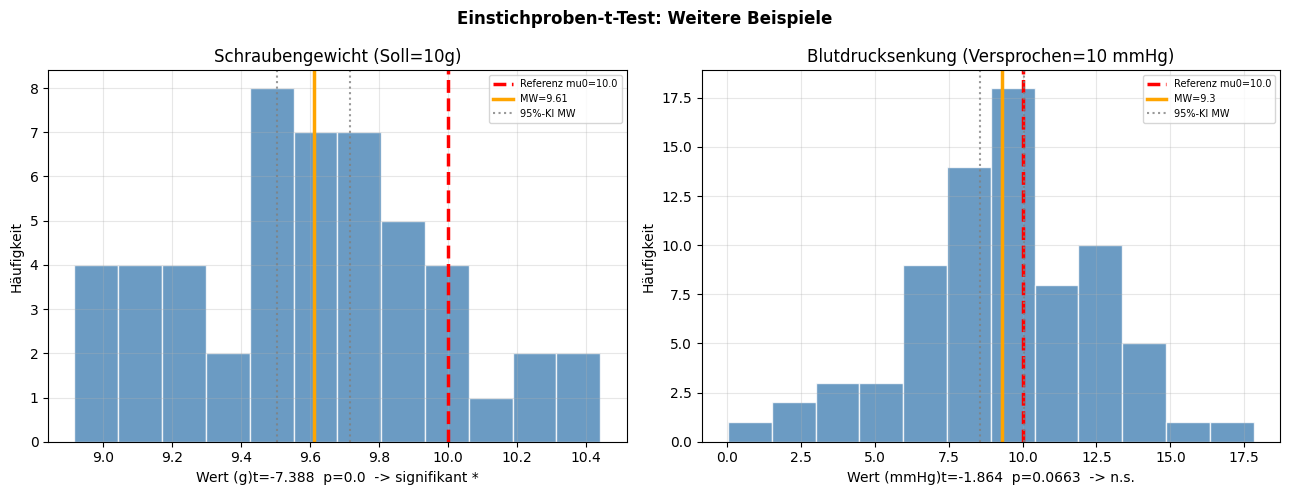

In [14]:
np.random.seed(42)

# Beispiel 1: Schrauben (technisch)
schrauben = pd.Series(np.random.normal(9.7, 0.4, 50))
mu_schraube = 10.0
t_sch, p_sch = stats.ttest_1samp(schrauben, popmean=mu_schraube)
ki_sch = t_dist.interval(0.95, df=len(schrauben)-1,
                          loc=schrauben.mean()-mu_schraube,
                          scale=schrauben.std(ddof=1)/np.sqrt(len(schrauben)))

print("Technisch: Schrauben-Gewicht")
print(f"Sollgewicht:      {mu_schraube} g")
print(f"Stichproben-MW:   {schrauben.mean():.3f} g  (n={len(schrauben)})")
print(f"t({len(schrauben)-1}) = {t_sch:.3f},  p = {p_sch:.4f}")
print(f"95%-KI Differenz: [{ki_sch[0]:.3f}, {ki_sch[1]:.3f}] g")
print("-> H0 " + ("ABGELEHNT" if p_sch < 0.05 else "nicht abgelehnt"))
print()

# Beispiel 2: Blutdruck (medizinisch)
blutdruck = pd.Series(np.random.normal(9.2, 3.5, 75))
mu_blutdruck = 10.0
t_bd, p_bd = stats.ttest_1samp(blutdruck, popmean=mu_blutdruck)
ki_bd = t_dist.interval(0.95, df=len(blutdruck)-1,
                         loc=blutdruck.mean()-mu_blutdruck,
                         scale=blutdruck.std(ddof=1)/np.sqrt(len(blutdruck)))

print("Medizinisch: Blutdrucksenkung")
print(f"Erwartete Senkung: {mu_blutdruck} mmHg")
print(f"Beobachtete Senkung: {blutdruck.mean():.3f} mmHg  (n={len(blutdruck)})")
print(f"t({len(blutdruck)-1}) = {t_bd:.3f},  p = {p_bd:.4f}")
print(f"95%-KI Differenz: [{ki_bd[0]:.3f}, {ki_bd[1]:.3f}] mmHg")
print("-> H0 " + ("ABGELEHNT" if p_bd < 0.05 else "nicht abgelehnt"))

# Visualisierung beider Beispiele
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Einstichproben-t-Test: Weitere Beispiele", fontsize=12, fontweight="bold")

for ax, daten, mu_r, einheit, titel in zip(
    axes,
    [schrauben, blutdruck],
    [mu_schraube, mu_blutdruck],
    ["g", "mmHg"],
    ["Schraubengewicht (Soll=10g)", "Blutdrucksenkung (Versprochen=10 mmHg)"]
):
    t_v, p_v = stats.ttest_1samp(daten, popmean=mu_r)
    n_v = len(daten)
    se_v = daten.std(ddof=1) / np.sqrt(n_v)
    ki_v = t_dist.interval(0.95, df=n_v-1, loc=daten.mean(), scale=se_v)

    ax.hist(daten, bins=12, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(mu_r, color="red", linestyle="--", linewidth=2.5,
               label="Referenz mu0=" + str(mu_r))
    ax.axvline(daten.mean(), color="orange", linestyle="-", linewidth=2.5,
               label="MW=" + str(round(daten.mean(), 2)))
    ax.axvline(ki_v[0], color="gray", linestyle=":", linewidth=1.5, alpha=0.8)
    ax.axvline(ki_v[1], color="gray", linestyle=":", linewidth=1.5, alpha=0.8,
               label="95%-KI MW")
    entsch = "signifikant *" if p_v < 0.05 else "n.s."
    ax.set_title(titel)
    ax.set_xlabel("Messwert (" + einheit + ")")
    ax.set_ylabel("Häufigkeit")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.set_xlabel("Wert (" + einheit + ")t=" + str(round(t_v, 3))
                  + "  p=" + str(round(p_v, 4)) + "  -> " + entsch)

plt.tight_layout()
plt.show()

## 6. Ergebnis im APA-Format

**numiqo-Beispiel laut Tutorial:**

> Ein t-Test ergab einen statistisch zuverlässigen Unterschied zwischen der Punktezahl
> von Studierenden, die den Online-Kurs besucht haben (M = 32,33, SD = 5,47) und der
> Durchschnitts-Punktezahl von Studierenden, die keinen Online-Kurs besucht haben,
> **t(11) = 2,75, p = .02**.

**Allgemeines APA-Format:**
```
t(df) = X.XX, p = .XXX, 95%-KI [u, o]
```

**Entscheidung über KI der Differenz:**
- KI **enthält nicht** 0 → signifikanter Unterschied ✅
- KI **enthält** 0 → kein signifikanter Unterschied ❌

In [15]:
# APA-Ausgabe für alle drei Beispiele
def einstichproben_ttest_apa(daten, mu_null, name="Variable",
                              gruppe_name="Stichprobe", alpha=0.05):
    d   = np.asarray(daten)
    n   = len(d)
    mw  = d.mean()
    s   = d.std(ddof=1)
    se  = s / np.sqrt(n)
    df  = n - 1
    t_v, p_v = stats.ttest_1samp(d, popmean=mu_null)
    ki  = t_dist.interval(0.95, df=df, loc=mw-mu_null, scale=se)
    ki_enthaelt_null = ki[0] <= 0 <= ki[1]

    print(f"APA-Ergebnis: {name}")
    print(f"Deskriptive Statistik: M={mw:.2f}, SD={s:.2f}, n={n}")
    print(f"Test gegen Referenzwert mu0={mu_null}")
    print()

    if p_v < 0.001:
        p_str = "p < .001"
    else:
        p_str = "p = " + str(round(p_v, 3)).replace("0.", ".")

    print(f"APA: t({df}) = {t_v:.2f}, {p_str}, "
          + f"95%-KI [{ki[0]:.2f}, {ki[1]:.2f}]")
    print()

    if not ki_enthaelt_null:
        print(f"Das Ergebnis ist statistisch signifikant (alpha={alpha}).")
        print(f"Die Nullhypothese (mu={mu_null}) wird abgelehnt.")
    else:
        print(f"Das Ergebnis ist nicht statistisch signifikant (alpha={alpha}).")
        print(f"Die Nullhypothese (mu={mu_null}) wird nicht abgelehnt.")
    print()

einstichproben_ttest_apa(punkte, 28.0,
    "Online-Tutorium", "Studierende mit Tutorium")
print()
einstichproben_ttest_apa(schrauben, 10.0,
    "Schraubengewicht", "Stichprobe Produktion")
print()
einstichproben_ttest_apa(blutdruck, 10.0,
    "Blutdrucksenkung", "Probanden mit Medikament")

APA-Ergebnis: Online-Tutorium
Deskriptive Statistik: M=32.33, SD=5.47, n=12
Test gegen Referenzwert mu0=28.0

APA: t(11) = 2.75, p = .019, 95%-KI [0.86, 7.81]

Das Ergebnis ist statistisch signifikant (alpha=0.05).
Die Nullhypothese (mu=28.0) wird abgelehnt.


APA-Ergebnis: Schraubengewicht
Deskriptive Statistik: M=9.61, SD=0.37, n=50
Test gegen Referenzwert mu0=10.0

APA: t(49) = -7.39, p < .001, 95%-KI [-0.50, -0.28]

Das Ergebnis ist statistisch signifikant (alpha=0.05).
Die Nullhypothese (mu=10.0) wird abgelehnt.


APA-Ergebnis: Blutdrucksenkung
Deskriptive Statistik: M=9.30, SD=3.23, n=75
Test gegen Referenzwert mu0=10.0

APA: t(74) = -1.86, p = .066, 95%-KI [-1.44, 0.05]

Das Ergebnis ist nicht statistisch signifikant (alpha=0.05).
Die Nullhypothese (mu=10.0) wird nicht abgelehnt.



## 7. Zusammenfassung

```
Einstichproben-t-Test – Übersicht
│
├── WANN?
│   Eine Stichprobe + bekannter Referenzwert (Norm, Soll, Standard)
│   NICHT für den Vergleich zweier Stichproben!
│
├── FORMEL
│   t = (x_quer - mu0) / (s / sqrt(n))
│   df = n - 1
│
├── SCHRITTE
│   1. Mittelwert x_quer berechnen
│   2. Standardabweichung s berechnen
│   3. Standardfehler SE = s / sqrt(n)
│   4. t-Wert berechnen
│   5. df = n - 1
│   6. t_krit aus Tabelle ablesen (oder p-Wert berechnen)
│   7. Entscheidung: |t| > t_krit  oder  p < alpha
│
├── HYPOTHESEN
│   Zweiseitig: H0: mu=mu0  vs.  H1: mu!=mu0
│   Einseitig rechts: H0: mu<=mu0  vs.  H1: mu>mu0
│   Einseitig links:  H0: mu>=mu0  vs.  H1: mu<mu0
│
├── ENTSCHEIDUNG
│   p < 0.05          -> H0 ablehnen (signifikant)
│   KI enthält 0     -> H0 nicht ablehnen
│   KI enthält nicht 0 -> H0 ablehnen
│
├── VORAUSSETZUNGEN
│   Metrisches Skalenniveau
│   Normalverteilung (ab n>30 robust)
│   Zufallsstichprobe
│
└── APA-FORMAT
    t(df) = X.XX, p = .XXX, 95%-KI [u, o]
    Beispiel: t(11) = 2.75, p = .02, 95%-KI [0.86, 7.81]
```

---
Quelle: [numiqo.de/tutorial/einfacher-t-test](https://numiqo.de/tutorial/einfacher-t-test)